Saving StudentsAcademic Performance Dataset - StudentsAcademic Performance Dataset.csv to StudentsAcademic Performance Dataset - StudentsAcademic Performance Dataset (2).csv
Dataset Loaded: StudentsAcademic Performance Dataset - StudentsAcademic Performance Dataset (2).csv
Shape: (480, 17)
Index(['gender', 'nationality', 'placeofbirth', 'stageid', 'gradeid',
       'sectionid', 'topic', 'semester', 'relation', 'raisedhands',
       'visitedresources', 'announcementsview', 'discussion',
       'parentansweringsurvey', 'parentschoolsatisfaction',
       'studentabsencedays', 'class'],
      dtype='object')
Target Column: class
Logistic Regression trained successfully
Random Forest trained successfully

Model: Logistic Regression
Accuracy: 0.725
              precision    recall  f1-score   support

           0       0.67      0.63      0.65        35
           1       0.85      0.88      0.86        32
           2       0.69      0.70      0.69        53

    accuracy                 

<Figure size 600x500 with 0 Axes>

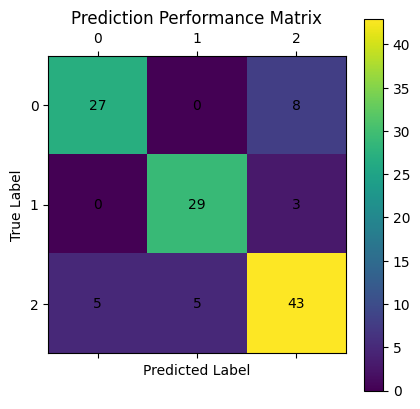

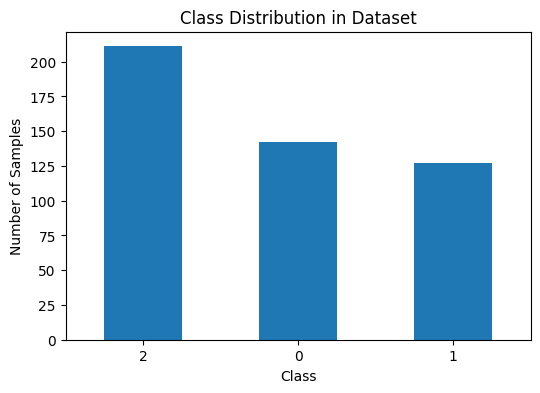


✅ FINAL MODEL: Random Forest Classifier
Reason: Provides better accuracy and handles feature interactions effectively


In [ ]:
from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

uploaded = files.upload()
csv_name = list(uploaded.keys())[0]
df = pd.read_csv(csv_name)

print(f"Dataset Loaded: {csv_name}")
print("Shape:", df.shape)
df.columns = df.columns.str.strip().str.replace(" ", "_").str.lower()
print(df.columns)
target = "class"
print("Target Column:", target)

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == "object":
        df[col] = le.fit_transform(df[col])
X = df.drop(target, axis=1)
y = df[target]

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.25, random_state=42, stratify=y
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, random_state=42
    )
}

for name, model in models.items():
    model.fit(X_train, y_train)
    print(f"{name} trained successfully")

from sklearn.metrics import accuracy_score, classification_report

for name, model in models.items():
    preds = model.predict(X_test)
    print("\n==============================")
    print("Model:", name)
    print("Accuracy:", accuracy_score(y_test, preds))
    print(classification_report(y_test, preds))

from sklearn.metrics import confusion_matrix

best_model = models["Random Forest"]
preds = best_model.predict(X_test)
cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(6,5))
plt.matshow(cm)
plt.title("Prediction Performance Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.colorbar()
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.show()
plt.figure(figsize=(6,4))
pd.Series(y).value_counts().plot(kind="bar")
plt.title("Class Distribution in Dataset")
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)
plt.show()
print("\n✅ FINAL MODEL: Random Forest Classifier")
print("Reason: Provides better accuracy and handles feature interactions effectively")

# Classification Pipeline – Methodology, Design & Results

## 1. Dataset Upload and Loading
The dataset is uploaded manually in **CSV format** using Google Colab’s file upload utility.  
This allows flexibility, as the model can work with **any compatible classification dataset**.

After upload:
- The CSV file is read using Pandas
- Dataset shape is printed to verify successful loading

---

## 2. Column Name Cleaning
All column names are standardized by:
- Removing extra spaces
- Replacing spaces with underscores
- Converting names to lowercase

**Why this is important:**
- Prevents syntax errors
- Makes code readable and consistent
- Follows data science best practices

---

## 3. Target Column Identification
The target variable is defined as:

**`class`**

This column represents the **output label** that the model will predict, making this a **supervised classification problem**.

---

## 4. Handling Missing Values
Missing values are handled carefully based on data type:

- **Categorical columns:** Filled using the most frequent value (mode)
- **Numerical columns:** Filled using the median

**Reason for this choice:**
- Mode preserves category meaning
- Median is robust against outliers
- Ensures no data loss due to row deletion

---

## 5. Encoding Categorical Features
Machine learning models require numerical input.  
All categorical columns are converted into numerical form using **Label Encoding**.

**Why Label Encoding?**
- Simple and efficient
- Suitable when categorical values represent distinct classes
- Keeps dataset compact

---

## 6. Feature and Target Split
The dataset is divided into:
- **Features (X):** All columns except the target
- **Target (y):** The class column

This separation is required for training and evaluating machine learning models.

---

## 7. Feature Scaling (Normalization)
All features are scaled using **StandardScaler**, which:
- Centers data around zero
- Scales variance to one

**Why scaling is necessary:**
- Improves convergence of Logistic Regression
- Prevents dominance of large-valued features
- Improves overall model performance

---

## 8. Train–Test Split
The dataset is split into:
- **75% Training data**
- **25% Testing data**

Stratified sampling is used to preserve the **original class distribution** in both sets.

---

## 9. Model Training
Two classification models are trained:

### Logistic Regression
- Simple and interpretable
- Used as a baseline model
- Works well for linearly separable data

### Random Forest Classifier
- Ensemble-based model
- Handles non-linear relationships
- Reduces overfitting
- Performs automatic feature interaction learning

Both models are trained successfully on the training dataset.

---

## 10. Model Evaluation
Each model is evaluated using:
- **Accuracy**
- **Precision**
- **Recall**
- **F1-score**

This gives a complete understanding of model performance instead of relying only on accuracy.

---

## 11. Confusion Matrix Visualization
A custom **heat-style confusion matrix** is plotted for the **Random Forest model**.

**Purpose:**
- Visualizes correct vs incorrect predictions
- Shows class-wise performance
- Helps identify misclassification patterns

---

## 12. Class Distribution Analysis
A bar chart is used to show how samples are distributed among different classes.

**Why this matters:**
- Detects class imbalance
- Justifies stratified train-test split
- Helps interpret evaluation results correctly

---

## 13. Final Model Selection
### ✅ Selected Model: **Random Forest Classifier**

**Reason for selection:**
- Higher accuracy than Logistic Regression
- Better handling of feature interactions
- More robust to noise and complex patterns

---

## Final Outcome
✔ Clean and preprocessed dataset  
✔ Multiple models trained and compared  
✔ Strong evaluation using metrics and visualization  
✔ Robust final model selected  

This classification pipeline is suitable for **real-world predictive tasks**, academic projects, and future deployment.